# Дополнительное задание 3

**Тема:** Работа со случайными величинами. Основные законы распределения.

В задании 1 использованы параметры нормального распределения из лабораторной работы 3: `m = 100`, `σ = 15`.



## Импорт библиотек


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon

# Чтобы графики отображались прямо в ноутбуке
%matplotlib inline

# Для воспроизводимости примеров можно зафиксировать зерно,
# но для задания 1 полезно иногда запускать без него.
# np.random.seed(42)


/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-rwy69nme because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Задание 1. Проверка правила «трех сигма»

Проверим правило «трех сигма» для нормально распределенной случайной величины с параметрами из лабораторной работы 3. Теоретически для нормального распределения вероятность попадания в интервал $(m-3\sigma;\,m+3\sigma)$ близка к $0.9973$. Это значение сравнивается с результатами моделирования.


In [2]:
# Параметры нормального распределения из лабораторной работы 3
mu_lab3 = 100      # математическое ожидание m
sigma_lab3 = 15    # стандартное отклонение sigma
sample_size = 500  # не менее 300, возьмем 500

In [3]:

# Генерация выборки
sample_normal = np.random.normal(loc=mu_lab3, scale=sigma_lab3, size=sample_size)

# Границы интервала трех сигма
left = mu_lab3 - 3 * sigma_lab3
right = mu_lab3 + 3 * sigma_lab3

# Эмпирическая частота попадания
freq = np.mean((sample_normal > left) & (sample_normal < right))

# Теоретическая вероятность
p_theoretical = norm.cdf(right, loc=mu_lab3, scale=sigma_lab3) - norm.cdf(left, loc=mu_lab3, scale=sigma_lab3)

print(f"Размер выборки: {sample_size}")
print(f"Интервал: ({left:.3f}; {right:.3f})")
print(f"Эмпирическая частота: {freq:.5f}")
print(f"Теоретическая вероятность: {p_theoretical:.5f}")
print(f"Абсолютное отклонение: {abs(freq - p_theoretical):.5f}")


Размер выборки: 500
Интервал: (55.000; 145.000)
Эмпирическая частота: 0.99600
Теоретическая вероятность: 0.99730
Абсолютное отклонение: 0.00130



### Несколько повторов эксперимента

По условию требуется несколько раз перезапустить код и посмотреть, как меняется частота. Ниже автоматизируем это наблюдение: проведем 10 независимых запусков и сравним результаты. При ручных перезапусках числа тоже будут немного меняться, что естественно из-за случайности выборки.


In [4]:

repeats = 10
freqs = []

for _ in range(repeats):
    x = np.random.normal(loc=mu_lab3, scale=sigma_lab3, size=sample_size)
    freqs.append(np.mean((x > left) & (x < right)))

freqs = np.array(freqs)
print("Частоты по запускам:", np.round(freqs, 5))
print(f"Средняя частота: {freqs.mean():.5f}")
print(f"Минимум: {freqs.min():.5f}")
print(f"Максимум: {freqs.max():.5f}")
print(f"Теоретическое значение: {p_theoretical:.5f}")


Частоты по запускам: [0.996 0.998 0.998 0.996 0.996 0.998 0.99  1.    1.    0.996]
Средняя частота: 0.99680
Минимум: 0.99000
Максимум: 1.00000
Теоретическое значение: 0.99730



### Вывод по заданию 1

В ходе моделирования получаются частоты, очень близкие к теоретическому значению вероятности попадания в интервал трех сигма. При повторных запусках частота немного изменяется, потому что выборка каждый раз генерируется заново, а значит в результат вносится случайная погрешность. Однако даже при этих колебаниях значение обычно остается близким к 0.9973.

Следовательно, правило «трех сигма» для нормально распределенной случайной величины подтверждается экспериментально: подавляющее большинство значений действительно попадает в интервал $(m-3\sigma;\,m+3\sigma)$. Небольшие отклонения между эмпирической частотой и теоретической вероятностью объясняются конечным объемом выборки.


## Задание 2. Проверка центральной предельной теоремы

Рассмотрим **показательное распределение** с параметром $\lambda = 2$. Это удобный пример, поскольку распределение непрерывное и несимметричное, поэтому эффект центральной предельной теоремы хорошо виден на графиках.


In [5]:

lam = 2
size_sample = 1000

# Для экспоненциального распределения scipy использует scale = 1/lambda
scale = 1 / lam

sample_exp = np.random.exponential(scale=scale, size=size_sample)

# Теоретические характеристики исходного распределения
mu = scale
sigma = scale

print(f"lambda = {lam}")
print(f"Математическое ожидание исходной СВ: {mu:.3f}")
print(f"Стандартное отклонение исходной СВ: {sigma:.3f}")


lambda = 2
Математическое ожидание исходной СВ: 0.500
Стандартное отклонение исходной СВ: 0.500



### Гистограмма выборки и график плотности исходного распределения


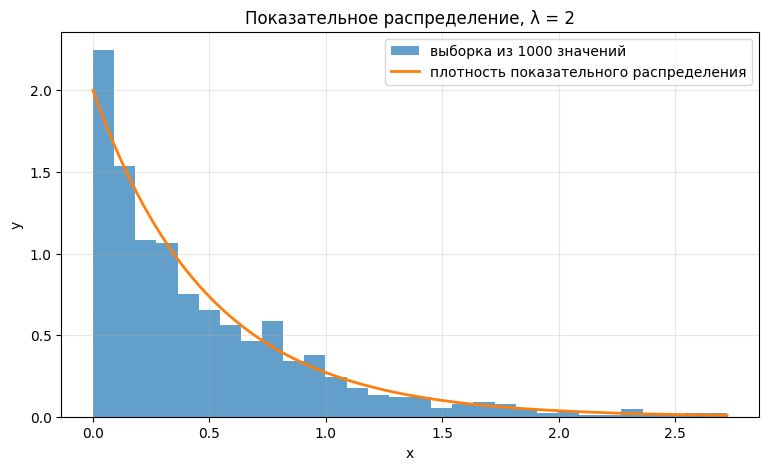

In [6]:

x = np.linspace(0, np.quantile(sample_exp, 0.995), 500)

plt.figure(figsize=(9, 5))
plt.hist(sample_exp, bins=30, range=(0, x.max()), density=True, alpha=0.7, label='выборка из 1000 значений')
plt.plot(x, expon.pdf(x, scale=scale), linewidth=2, label='плотность показательного распределения')
plt.title(f'Показательное распределение, λ = {lam}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



По графику видно, что эмпирическая гистограмма хорошо повторяет форму показательного распределения: максимум расположен около нуля, затем плотность убывает. Это важно, потому что далее мы будем усреднять именно такие случайные величины.


### Генерация выборок для случайной величины

Рассматриваем величину

$$
\overline{X} = \frac{1}{n}\sum_{k=1}^{n} X_k,
$$

где $X_k$ — независимые случайные величины с выбранным показательным распределением. Для каждого значения $n$ сгенерируем 1000 значений случайной величины $\overline{X}$.


In [7]:

def sample_means_exponential(n, experiments=1000, lam=2):
    scale = 1 / lam
    samples = np.random.exponential(scale=scale, size=(experiments, n))
    return samples.mean(axis=1)

n_values = [5, 10, 50, 100]



### Теоретические параметры нормального приближения

Согласно центральной предельной теореме, распределение среднего $\overline{X}$ при достаточно больших $n$ приближается нормальным распределением

$$
\overline{X} pprox N\left(\mu, rac{\sigma}{\sqrt{n}}ight),
$$

где $\mu$ — математическое ожидание исходной случайной величины, а $\sigma$ — ее стандартное отклонение. Для показательного распределения с $\lambda = 2$ имеем:

- $\mu = 1/\lambda = 0.5$,
- $\sigma = 1/\lambda = 0.5$.


In [8]:

for n in n_values:
    mu_n = mu
    sigma_n = sigma / np.sqrt(n)
    print(f"n = {n:3d}: m = {mu_n:.4f}, sigma = {sigma_n:.4f}")


n =   5: m = 0.5000, sigma = 0.2236
n =  10: m = 0.5000, sigma = 0.1581
n =  50: m = 0.5000, sigma = 0.0707
n = 100: m = 0.5000, sigma = 0.0500



### Гистограммы распределения $\overline{X}$ и графики нормальной плотности


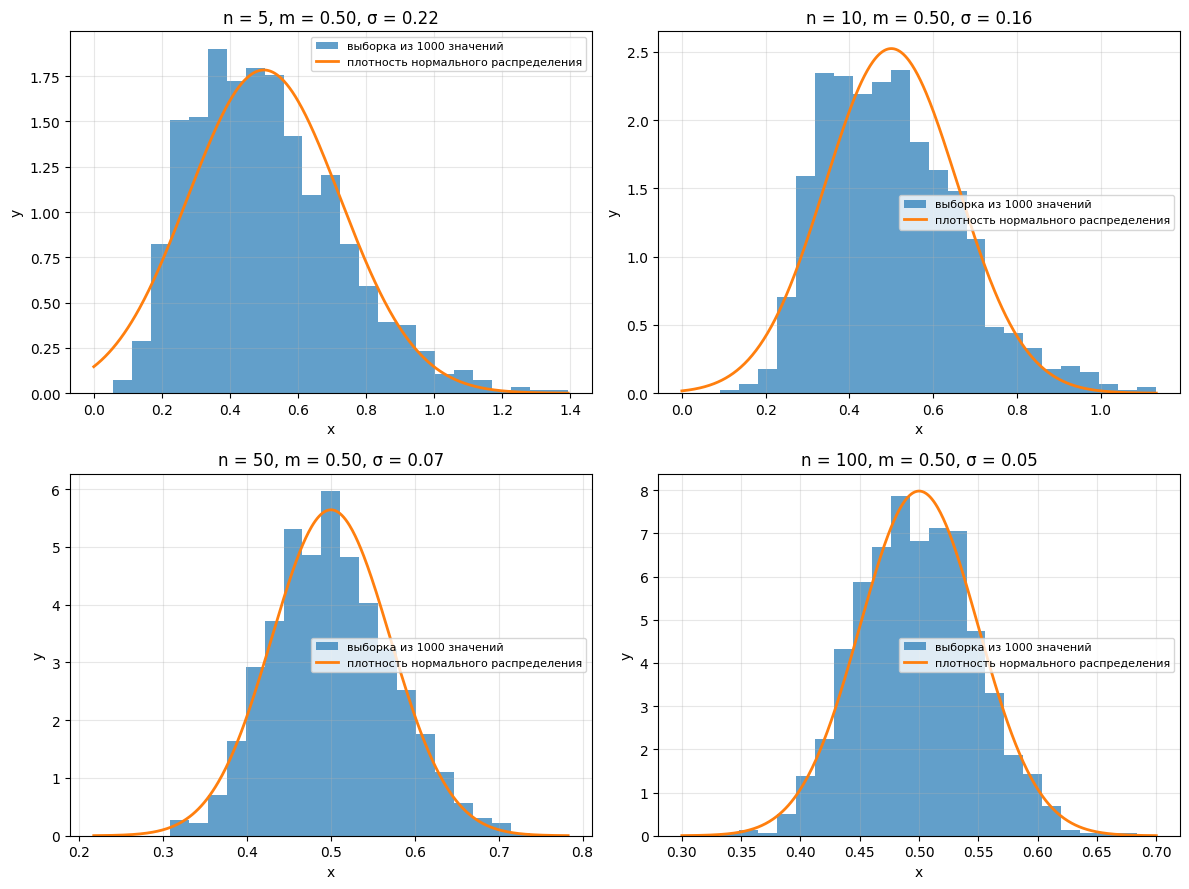

In [9]:

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, n in zip(axes, n_values):
    means_sample = sample_means_exponential(n=n, experiments=1000, lam=lam)
    mu_n = mu
    sigma_n = sigma / np.sqrt(n)

    x_min = max(0, mu_n - 4 * sigma_n)
    x_max = mu_n + 4 * sigma_n
    x_grid = np.linspace(x_min, x_max, 500)

    ax.hist(means_sample, bins=25, range=(x_min, x_max), density=True,
            alpha=0.7, label='выборка из 1000 значений')
    ax.plot(x_grid, norm.pdf(x_grid, loc=mu_n, scale=sigma_n), linewidth=2,
            label='плотность нормального распределения')
    ax.set_title(f'n = {n}, m = {mu_n:.2f}, σ = {sigma_n:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



### Вывод по заданию 2

По построенным графикам видно, что уже при сравнительно небольших значениях $n$ распределение среднего $\overline{X}$ становится более симметричным и все больше похоже на нормальное распределение. При $n=5$ различия еще заметны, но форма распределения уже напоминает колоколообразную. При $n=10$ совпадение становится лучше, а при $n=50$ и $n=100$ гистограмма практически накладывается на график нормальной плотности.

Таким образом, увеличение $n$ делает распределение среднего арифметического ближе к нормальному. Одновременно уменьшается стандартное отклонение $\sigma/\sqrt{n}$, поэтому распределение становится более узким и сильнее концентрируется около математического ожидания.

Полученные результаты согласуются с центральной предельной теоремой: даже если исходное распределение не является нормальным и заметно асимметрично, распределение среднего большого числа независимых одинаково распределенных случайных величин стремится к нормальному.


## Итог

1. Проверено правило «трех сигма» для нормального распределения с помощью моделирования и сравнения с теоретической вероятностью.
2. Проведено исследование, иллюстрирующее работу центральной предельной теоремы на примере показательного распределения.
